Last edited: 1/28/2026, 3:38 PM CST
# Assessing how important the scale parameter is in determining return levels

Computing the sensitivity of the return level to the location and scale parameters.

In [ ]:
# import base packages for data analysis
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from evt_heat_waves.config import MIP_FIT_PATH_DICT, FIGS_PATH

from evt_heat_waves.utils import extract_model_name
from evt_heat_waves.mip_fit.cmip_dataclass import CMIP6EnsembleConfig
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.utils import make_figure_filename
from evt_heat_waves.plotting.scale_param import (get_era5_dataset, 
                                                 get_cmip_locs_scales, 
                                                 get_critical_return_period_dataset, 
                                                 percent_above_below_threshold)

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

SAVE_FIGS = True

%load_ext autoreload
%autoreload 2

# First plot: Contours of partial deriviatives

In [2]:
def dscale_dmu(ret_period, shape):
    ret_probs = 1 - ret_period**(-1)
    if shape == 0:
        dxp_dscale = -np.log(
            -np.log(
                ret_probs
            )
        )
    else:
        dxp_dscale = (-1/shape) * (
            1 - (
                -np.log(ret_probs)
            )**(-shape)
        )

    dxp_dloc = 1.0

    return dxp_dscale / dxp_dloc

In [3]:
dshape = 0.01
shapes = np.arange(-4, dshape, dshape)
shapes[-1] = 0.0
shapes

array([-4.  , -3.99, -3.98, -3.97, -3.96, -3.95, -3.94, -3.93, -3.92,
       -3.91, -3.9 , -3.89, -3.88, -3.87, -3.86, -3.85, -3.84, -3.83,
       -3.82, -3.81, -3.8 , -3.79, -3.78, -3.77, -3.76, -3.75, -3.74,
       -3.73, -3.72, -3.71, -3.7 , -3.69, -3.68, -3.67, -3.66, -3.65,
       -3.64, -3.63, -3.62, -3.61, -3.6 , -3.59, -3.58, -3.57, -3.56,
       -3.55, -3.54, -3.53, -3.52, -3.51, -3.5 , -3.49, -3.48, -3.47,
       -3.46, -3.45, -3.44, -3.43, -3.42, -3.41, -3.4 , -3.39, -3.38,
       -3.37, -3.36, -3.35, -3.34, -3.33, -3.32, -3.31, -3.3 , -3.29,
       -3.28, -3.27, -3.26, -3.25, -3.24, -3.23, -3.22, -3.21, -3.2 ,
       -3.19, -3.18, -3.17, -3.16, -3.15, -3.14, -3.13, -3.12, -3.11,
       -3.1 , -3.09, -3.08, -3.07, -3.06, -3.05, -3.04, -3.03, -3.02,
       -3.01, -3.  , -2.99, -2.98, -2.97, -2.96, -2.95, -2.94, -2.93,
       -2.92, -2.91, -2.9 , -2.89, -2.88, -2.87, -2.86, -2.85, -2.84,
       -2.83, -2.82, -2.81, -2.8 , -2.79, -2.78, -2.77, -2.76, -2.75,
       -2.74, -2.73,

In [4]:
def get_when_equal(shapes, multiple):
    when_equal = np.zeros_like(shapes)
    when_equal[shapes != 0] = np.e**(
        -(
            1+multiple*shapes[shapes != 0] 
        )**(-1/shapes[shapes != 0])
    )
    when_equal[shapes == 0] = np.e**(-np.e**(-multiple))
    return when_equal

In [5]:
multiples = np.arange(0.01, 7.0, 0.05)

# Create a 2D array to store return periods for each shape and multiple
ret_periods_grid = np.zeros((len(shapes), len(multiples)))

# Compute return periods for each multiple
for j, multiple in enumerate(multiples):
    when_equal_tmp = get_when_equal(shapes, multiple)
    ret_periods_grid[:, j] = 1 / (1 - when_equal_tmp)

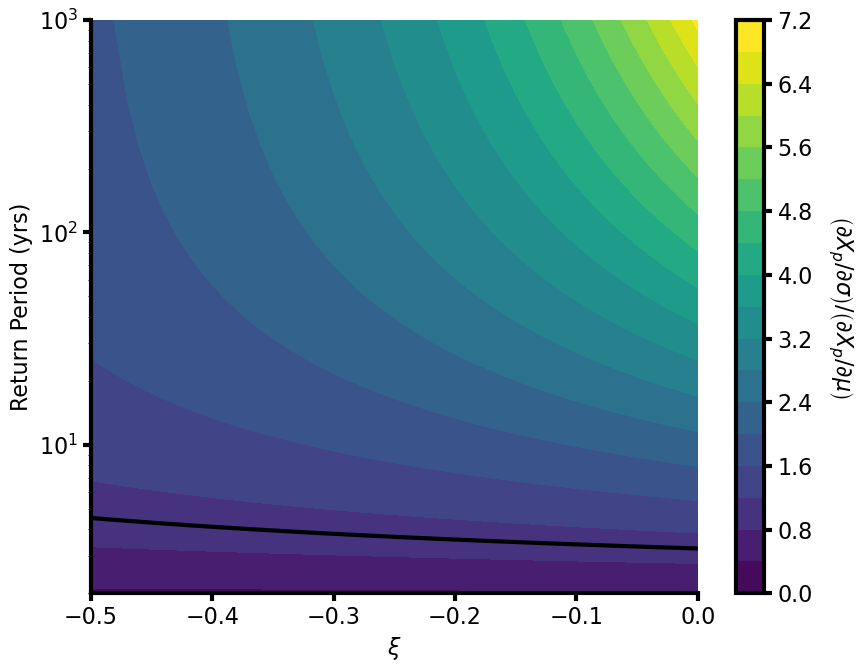

In [6]:
from matplotlib.colors import Normalize

# All three arrays: shape (len(shapes), len(multiples))
X = np.tile(shapes[:, None], (1, len(multiples)))       # shape value, repeated across multiples
Y = ret_periods_grid                                      # return period, already computed
Z = np.tile(multiples[None, :], (len(shapes), 1))         # multiple value, repeated across shapes

fig, axes = plt.subplots(figsize=(9, 7))

norm = Normalize(vmin=multiples.min(), vmax=multiples.max())

# --- Filled contour ---
cf = axes.contourf(X, Y, Z, levels=20, norm=norm, cmap='viridis')
axes.set_yscale('log')
axes.set_xlabel(r'$\xi$')
axes.set_ylabel('Return Period (yrs)')
axes.set_ylim(2, 1000)
axes.set_xlim(-0.5, 0)

axes.contour(X, Y, Z, levels=[1.0], colors='k', linewidths=3)
cbar = fig.colorbar(cf, ax=axes)
cbar.set_label(label=r'$\left(\partial X_{p} / \partial \sigma \right) / \left( \partial X_{p} / \partial \mu \right)$', rotation=270, labelpad=30)

plt.tight_layout()
plt.show()

# Second plot: Spatial plot where misfits in sigma become bigger than misfits in mu for determining return levels

In [ ]:
def get_ds_crit(fit, anom_type, ex_type, YEAR, mip='cmip', TMIN=1979, GRID='1deg'):
    data_type = 'raw' if anom_type == 'raw' else f"anom_{anom_type}"
    era5_variable = f't2m_annual_{ex_type}'
    cmip_variable = f'tas_annual_{ex_type}'

    if 'gumbel' in fit:
        xi = 0.0
    elif 'minxi' in fit:
        xi = -0.5
    elif 'klein' in fit:
        xi = -0.25
    else:
        print("WARNING: unable to find fit -> xi mapping, setting to zero but please check!")

    # set config
    era5_config = {
        'var': era5_variable,
        'fit': fit,
        'TMIN': TMIN,
        'anom': anom_type,
        'GRID': GRID
    }

    NORMALIZED_YEAR = (YEAR - TMIN) / (2024 - TMIN)  # normalized time point to eval trends

    # import era5 dataset
    ds_era5 = get_era5_dataset(era5_config)

    CMIPConfig = CMIP6EnsembleConfig.from_yaml(
        MIP_FIT_PATH_DICT[mip]['config']['meta'],
        MIP_FIT_PATH_DICT[mip]['config']['qc']
    )

    N_active_models = len(list(CMIPConfig.iter_active_models(cmip_variable)))

    # make file/model matcher for 
    data_path = MIP_FIT_PATH_DICT[mip]['data'] / cmip_variable / 'gev'

    # Make all landonly file names
    fnames = [f for f in data_path.glob(f"*_{fit}_*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

    modelname_filepath_matcher = {
        extract_model_name(f): f for f in fnames
    }

    cmip_data_config = {
        'fit': fit,
        'var': cmip_variable,
        'model_file_matcher': modelname_filepath_matcher,
        'data_type': data_type,
        'N_active_models': N_active_models
    }

    ds_cmip = get_cmip_locs_scales(cmip_data_config, CMIPConfig, ds_era5, NORMALIZED_YEAR)
    ds_crit = get_critical_return_period_dataset(ds_cmip, ds_era5, data_type, NORMALIZED_YEAR, xi=xi)
    return ds_crit


In [ ]:
TMIN_HISTORICAL = 1979

print("------- Computing critical return periods in the historical record -------")
print("> xi = 0")
ds_crit_gumbel_hist = get_ds_crit('nonstat_gumbel_only_loc_trend', 'annmean', 'max',
                                  YEAR=TMIN_HISTORICAL)
print("> xi = -1/4")
#ds_crit_minxi_hist = get_ds_crit('nonstat_minxi_only_loc_trend', 'annmean', 'max',
#                                  YEAR=TMIN_HISTORICAL)

print("> xi = -1/2")
#ds_crit_klein_hist = get_ds_crit('nonstat_kleinxi_only_loc_trend', 'annmean', 'max', 
#                                  YEAR=TMIN_HISTORICAL)

PROJ_YEAR = 2050
print(f"------- Computing critical return periods in {PROJ_YEAR} -------")
print("> xi = 0")
ds_crit_gumbel_proj = get_ds_crit('nonstat_gumbel_only_loc_trend', 'annmean', 'max',
                                  YEAR=PROJ_YEAR)

print("> xi = -1/4")
#ds_crit_minxi_proj = get_ds_crit('nonstat_minxi_only_loc_trend', 'annmean', 'max',
#                                  YEAR=PROJ_YEAR)

print("> xi = -1/2")
#ds_crit_klein_proj = get_ds_crit('nonstat_kleinxi_only_loc_trend', 'annmean', 'max', 
#                                  YEAR=PROJ_YEAR)


------- Computing critical return periods in the historical record -------
> xi = 0
⚒️ Working on AWI-CM-1-1-MR...
⚒️ Working on BCC-CSM2-MR...
⚒️ Working on CAMS-CSM1-0...
⚒️ Working on CESM2-WACCM...
⚒️ Working on CMCC-CM2-SR5...
⚒️ Working on CMCC-ESM2...
⚒️ Working on CNRM-CM6-1-HR...
⚒️ Working on CNRM-ESM2-1...
⚒️ Working on EC-Earth3-CC...
⚒️ Working on EC-Earth3-Veg...
⚒️ Working on EC-Earth3-Veg-LR...
⚒️ Working on FGOALS-g3...
⚒️ Working on GFDL-CM4...
⚒️ Working on GFDL-ESM4...
⚒️ Working on HadGEM3-GC31-LL...
⚒️ Working on HadGEM3-GC31-MM...
⚒️ Working on IITM-ESM...
⚒️ Working on INM-CM4-8...
⚒️ Working on INM-CM5-0...
⚒️ Working on KACE-1-0-G...
⚒️ Working on KIOST-ESM...
⚒️ Working on MIROC-ES2L...
⚒️ Working on MIROC6...
⚒️ Working on MPI-ESM1-2-HR...
⚒️ Working on MPI-ESM1-2-LR...
⚒️ Working on NorCPM1...
⚒️ Working on NorESM2-LM...
⚒️ Working on TaiESM1...
⚒️ Working on UKESM1-0-LL...
> xi = -1/4
> xi = -1/2
------- Computing critical return periods in 2050 -------
> 

# Make components of main figure

saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-15-panela-contours.svg


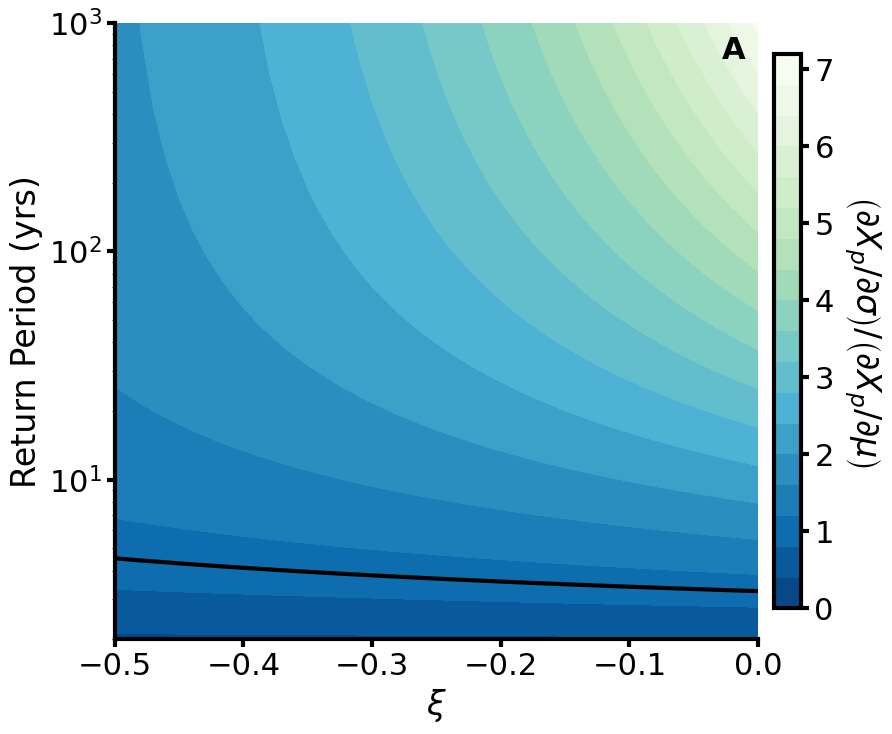

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))

gs = GridSpec(
    1, 1,
    figure=fig,
    wspace=0.15,
    hspace=0.15
)

ax_a = fig.add_subplot(gs[0])

X = np.tile(shapes[:, None], (1, len(multiples)))
Y = ret_periods_grid
Z = np.tile(multiples[None, :], (len(shapes), 1))

norm_a = Normalize(vmin=multiples.min(), vmax=multiples.max())

cf = ax_a.contourf(X, Y, Z, levels=20, norm=norm_a, cmap='GnBu_r')
ax_a.set_yscale('log')
ax_a.set_xlabel(r'$\xi$', fontsize=24)
ax_a.set_ylabel('Return Period (yrs)', fontsize=24)
ax_a.set_ylim(2, 1000)
ax_a.set_xlim(-0.5, 0)

ax_a.contour(X, Y, Z, levels=[1.0], colors='k', linewidths=3)
cbar_a = fig.colorbar(cf, ax=ax_a, shrink=0.9, pad=0.02, ticks=[0,1,2,3,4,5,6,7])
cbar_a.set_label(
    label=r'$\left(\partial X_{p} / \partial \sigma \right) / \left( \partial X_{p} / \partial \mu \right)$',
    rotation=270, labelpad=35, fontsize=24
)
cbar_a.ax.tick_params(labelsize=22)

label = 'A'
ax_a.text(
    0.98,
    0.98,
    label,
    fontsize=22,
    transform=ax_a.transAxes,
    color='k',
    fontweight='bold',
    va='top',
    ha='right'
)

ax_a.tick_params('both', labelsize=22)

if SAVE_FIGS:
    filename = make_figure_filename('panela-contours', FIGS_PATH, 'svg')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f'saved to: {filename}')

plt.show()

In [10]:
np.e

2.718281828459045

saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-16-panela-contours-xi0.png


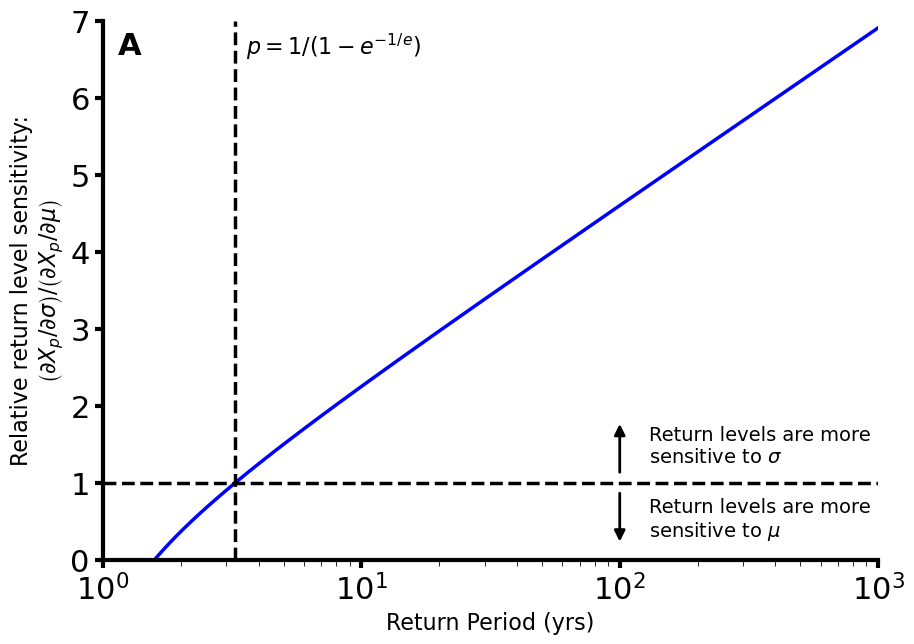

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 7))

gs = GridSpec(
    1, 1,
    figure=fig,
    wspace=0.15,
    hspace=0.15
)

ax_a = fig.add_subplot(gs[0])

ret_periods = [1 / (1 - get_when_equal(np.array([-1e-10]), multiple)) for multiple in multiples]

norm_a = Normalize(vmin=multiples.min(), vmax=multiples.max())

cf = ax_a.plot(ret_periods, multiples, color='blue')
ax_a.axhline(1.0, linestyle='dashed', color='k')
ax_a.axvline(
    (
        1-np.exp(-np.exp(-1))
    )**(-1),
    linestyle='dashed',
    color='k'
)

ax_a.set_xscale('log')
ax_a.set_xlabel(r"Return Period (yrs)")
ax_a.set_ylabel(
    "Relative return level sensitivity:\n"
    r"$\left(\partial X_p / \partial \sigma\right)"
    r"/"
    r"\left(\partial X_p / \partial \mu\right)$"
)
ax_a.set_ylim((0, 7))
ax_a.set_xlim((1, 10**3))

label = 'A'
ax_a.text(
    0.05,
    0.98,
    label,
    fontsize=22,
    transform=ax_a.transAxes,
    color='k',
    fontweight='bold',
    va='top',
    ha='right'
)

ax_a.text(
    0.41,
    0.98,
    r"$p = 1/(1-e^{-1/e})$",
    fontsize=16,
    transform=ax_a.transAxes,
    color='k',
    va='top',
    ha='right'
)

ax_a.tick_params('both', labelsize=22)

# pick an x location (in data coords) where there's empty space, e.g. return period ~5
x_arrow = 100
dy = 0.8  # how far above/below y=1 each arrow extends

# upward arrow: from y=1 up to y=1+dy
ax_a.annotate(
    '',
    xy=(x_arrow, 1 + dy),
    xytext=(x_arrow, 1.1),
    arrowprops=dict(arrowstyle='-|>', color='k', lw=2)
)

# downward arrow: from y=1 down to y=1-dy
ax_a.annotate(
    '',
    xy=(x_arrow, 1 - dy),
    xytext=(x_arrow, 0.9),
    arrowprops=dict(arrowstyle='-|>', color='k', lw=2)
)

# text box next to the upward arrow
ax_a.text(
    x_arrow * 1.3, 1 + dy * 0.6,
    'Return levels are more\nsensitive to $\\sigma$',
    fontsize=14,
    ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=None, alpha=0.9)
)

# text box next to the downward arrow
ax_a.text(
    x_arrow * 1.3, 1 - dy * 0.6,
    'Return levels are more\nsensitive to $\\mu$',
    fontsize=14,
    ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=None, alpha=0.9)
)

ax_a.tick_params(which='minor', length=4)

if SAVE_FIGS:
    filename = make_figure_filename('panela-contours-xi0', FIGS_PATH, 'png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f'saved to: {filename}')

plt.show()

In [66]:
def make_map_crits(ds_crit, label, xi, title=None):
    if title is None:
        title = r'$\xi = $' + str(xi)

    fig = plt.figure(figsize=(10, 8))

    gs = GridSpec(
        1, 1,
        figure=fig,
    )

    ax_a = fig.add_subplot(gs[0], projection=ccrs.EqualEarth())

    # ---------------------------------------------------------------
    # Shared colormap/norm for panels (b) and (c)
    # ---------------------------------------------------------------
    levels = [0, 1, 2, 3, 4]  # log10 of [1, 10, 100, 1000]
    cbar_labels = [1, 10, 100, 1000, r'$>$1000']

    cmap_map = plt.get_cmap('GnBu', len(levels) - 1)
    cmap_map.set_over(cmap_map(cmap_map.N - 1))
    norm_map = mcolors.BoundaryNorm(levels, cmap_map.N)
    CBAR_SHRINK = 0.6

    # ---------------------------------------------------------------
    # Panel (b): crit_ps spatial plot
    # ---------------------------------------------------------------
    im_b = ds_crit.crit_ps.plot(
        ax=ax_a, transform=ccrs.PlateCarree(),
        cmap=cmap_map, norm=norm_map, add_colorbar=False
    )

    ax_a.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax_a.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax_a.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    ax_a.add_feature(cfeature.OCEAN, facecolor="white")
    ax_a.set_title(title, pad=12)

    cbar_b = fig.colorbar(im_b, ax=ax_a, extend='max', ticks=levels,
                        shrink=CBAR_SHRINK, pad=0.05)
    cbar_b.ax.set_yticklabels(cbar_labels)
    cbar_b.set_label('Return Period (yrs)')
    
    ax_a.text(
        0.98,
        1.05,
        label,
        transform=ax_a.transAxes,
        color='k',
        fontweight='bold',
        va='top',
        ha='right'
    )

    if SAVE_FIGS:
        filename = make_figure_filename(f'panel{label}-plot-returnperiods', FIGS_PATH, 'svg')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f'saved to: {filename}')

saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-15-panelA-plot-returnperiods.svg


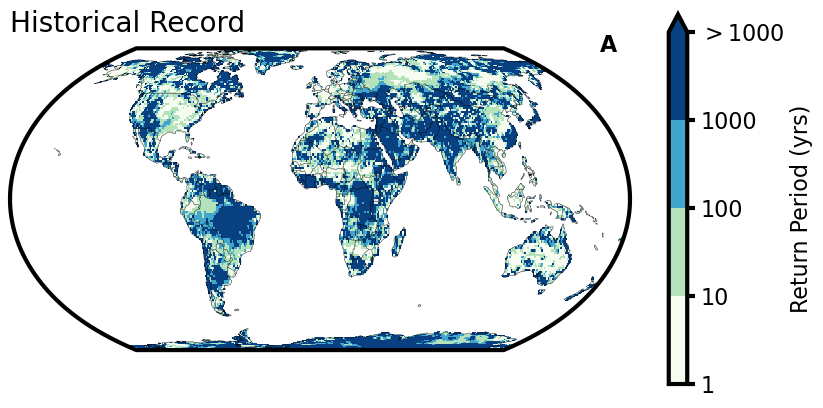

In [67]:
make_map_crits(ds_crit_gumbel_hist, 'A', 0.0, 'Historical Record')
#make_map_crits(ds_crit_klein_hist, 'D', -0.25)
#make_map_crits(ds_crit_minxi_hist, 'F', -0.5)

saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-15-panelB-plot-returnperiods.svg


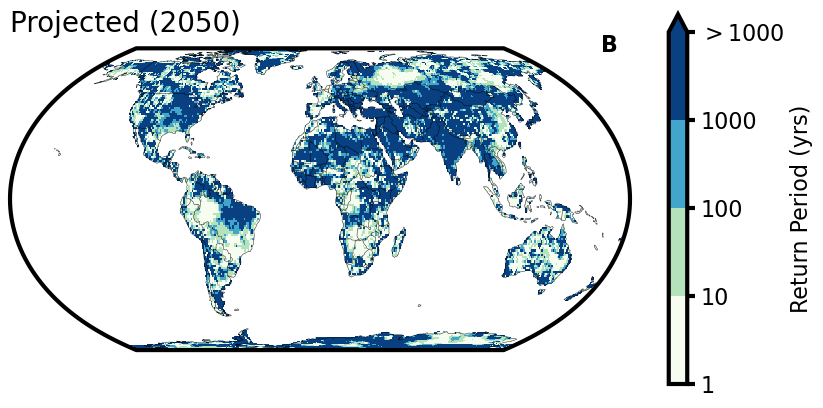

In [68]:
make_map_crits(ds_crit_gumbel_proj, 'B', 0.0, "Projected (2050)")
#make_map_crits(ds_crit_klein_proj, 'E', -0.25)
#make_map_crits(ds_crit_minxi_proj, 'G', -0.5)

Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-15-merged_hist_proj.png


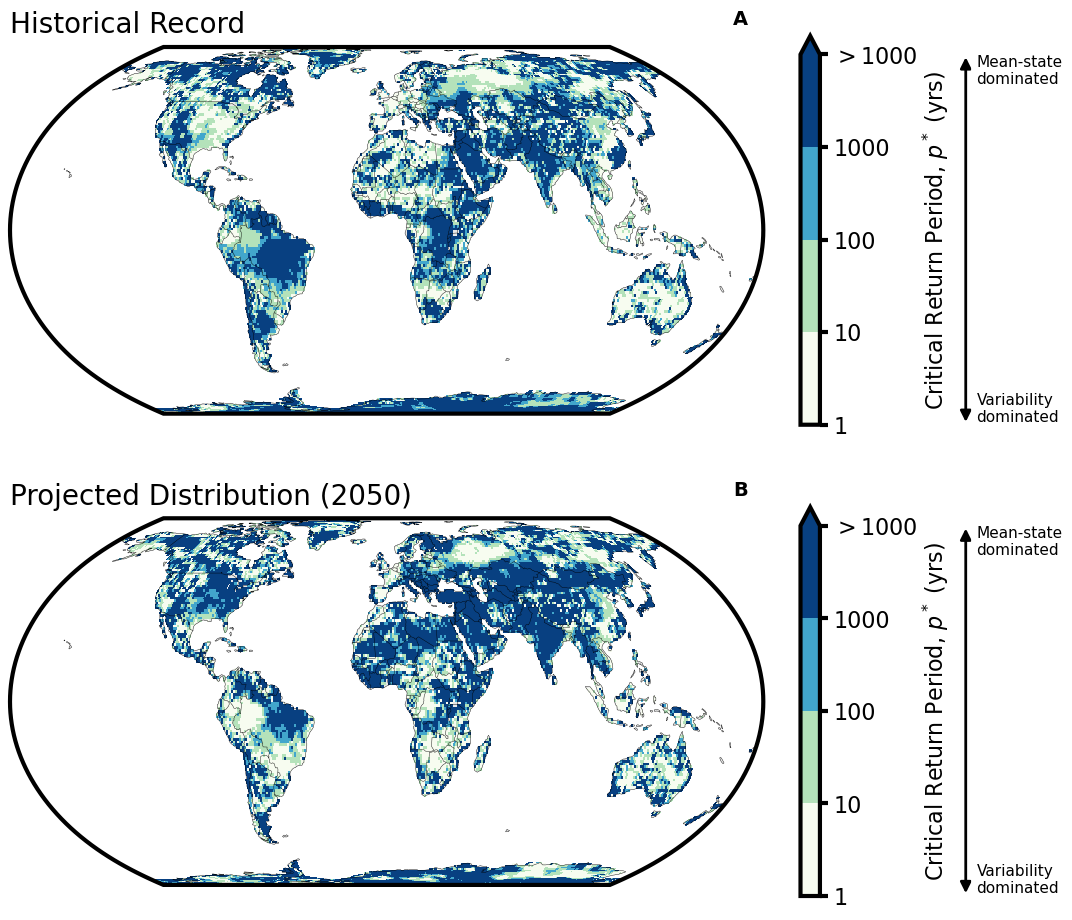

In [93]:
# Set up the plotting grid
fig, axes = plt.subplots(
    2,
    figsize=(12, 16),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

das = [ds_crit_gumbel_hist.crit_ps, ds_crit_gumbel_proj.crit_ps]
titles = ['Historical Record', 'Projected Distribution (2050)']

for idx, (ax, da, title) in enumerate(zip(axes.flatten(), das, titles)):
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # ---------------------------------------------------------------
    levels = [0, 1, 2, 3, 4]  # log10 of [1, 10, 100, 1000]
    cbar_labels = ['1', '10', '100', '1000', r'$>$1000']

    cmap_map = plt.get_cmap('GnBu', len(levels) - 1)
    cmap_map.set_over(cmap_map(cmap_map.N - 1))
    norm_map = mcolors.BoundaryNorm(levels, cmap_map.N)

    # Plot the parameter
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_map,
        norm=norm_map,
        add_colorbar=False,
    )
    ax.set_title(title, pad=10)

    # Add an aligned colorbar on the right of each plot
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.99)
    cbar.set_label(r"Critical Return Period, $p^*$ (yrs)", labelpad=2.5)
    cbar.set_ticklabels(cbar_labels)
    # cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))

    # --- double-headed arrow to the right of the colorbar ---
    x_arrow = 8.5  # push right past the tick labels; increase if it overlaps text

    cbar.ax.annotate(
        '',
        xy=(x_arrow, 1.0),      # top, in colorbar-axes fraction coords
        xytext=(x_arrow, 0.0),  # bottom
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(arrowstyle='<|-|>', color='k', lw=2),
        annotation_clip=False,
    )

    # text box at the top of the arrow
    cbar.ax.text(
        x_arrow + 0.55, 1.0,
        'Mean-state\ndominated',
        transform=cbar.ax.transAxes,
        fontsize=11,
        ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=None, alpha=0.9),
        clip_on=False,
    )

    # text box at the bottom of the arrow
    cbar.ax.text(
        x_arrow + 0.55, 0.0,
        'Variability\ndominated',
        transform=cbar.ax.transAxes,
        fontsize=11,
        ha='left', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=None, alpha=0.9),
        clip_on=False,
    )

#for ax in axes.flatten():
#    ax.set_global()

# add labels
panel_labels = ['A', 'B']
for idx, ax in enumerate(axes.flatten()):
    ax.text(
        0.98,
        1.05,
        f"{panel_labels[idx]}",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.subplots_adjust(top=0.6, bottom=0.06)

if SAVE_FIGS:
    fname = make_figure_filename(name='merged_hist_proj', outdir=FIGS_PATH)
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {fname}")
    
plt.show()

In [15]:
"""Composite figure builder for the return-period / crit_ps panel figure.

Builds the full multi-panel figure (contour sensitivity panel + two
crit_ps maps, one per passed dataset) in a single matplotlib figure, so
there's no PNG -> Keynote -> JPEG round trip and no quality loss from
rasterizing/recompressing panels that were already vector.

Layout: three panels stacked in a single column --
    A. contour sensitivity panel (top)
    B. crit_ps map for `ds1`     (middle)
    C. crit_ps map for `ds2`     (bottom)

Adam Michael Bauer
University of Chicago
"""

import os
import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def _default_filename(name, figs_path, ext):
    """Fallback filename builder if no filename_func is supplied.

    Mirrors the '<figs_path>/YYYY-M-D-<name>.<ext>' pattern used by the
    existing plotting presets.
    """
    today = datetime.datetime.now()
    prefix = f'{today.year}-{today.month}-{today.day}-'
    os.makedirs(figs_path, exist_ok=True)
    return os.path.join(figs_path, f'{prefix}{name}.{ext}')


def make_fig4(
    shapes,
    multiples,
    ret_periods_grid,
    ds1,
    ds2,
    ds1_title='Historical Record',
    ds2_title='Projected (2050)',
    figsize=(9, 15),
    height_ratios=(1, 1.2, 1.2),
    subfig_hspace=0.08,
    panel_width_ratios=(1, 0.05, 0.32),
    panel_wspace=0.08,
    panelA_fontsize=20,
    panelA_ticksize=16,
    map_title_fontsize=14,
    map_label_fontsize=16,
    cbar_label_fontsize=12,
    save_figs=False,
    figs_path=None,
    filename_func=None,
    save_formats=('png'),
    dpi=300,
):
    """Build the full composite figure: panel A (contour) stacked above
    two crit_ps map panels (B, C), one per dataset, all in one column.

    Parameters
    ----------
    shapes : array-like
        Shape parameter (xi) values spanning the x-axis of panel A, e.g.
        np.linspace(-4, 0, 401). Only the (-0.5, 0) window is shown, matching
        the original contour script.
    multiples : array-like
        Values along the panel A color axis (the sensitivity-ratio values).
    ret_periods_grid : 2D array
        Return-period grid (Y) for panel A, same shape as the meshgrid built
        from `shapes` and `multiples`.
    ds1, ds2 : xarray.Dataset
        Each must have a `crit_ps` variable on (lat, lon). `ds1` is drawn in
        the middle panel (B), `ds2` in the bottom panel (C). Both share the
        same colormap/norm so they're directly comparable.
    ds1_title, ds2_title : str, default 'Historical Record', 'Projected (2050)'
        Title text shown above each map panel. Swap these (and swap ds1/ds2)
        if your two datasets represent something else.
    figsize : tuple, default (9, 15)
        Tall/narrow default since all three panels now stack in a single
        column rather than sitting side by side.
    height_ratios : tuple of 3 floats
        Relative height of [panel A, panel B, panel C].
    subfig_hspace : float
        Vertical spacing between the three stacked subfigures.
    panel_width_ratios : tuple of 3 floats
        Shared [main-axis, colorbar, side-annotation] width ratios used by
        every panel's internal GridSpec so the three main axes line up
        vertically. Panel A doesn't use the side-annotation column -- it's
        left blank purely so its plot area lines up with the maps below.
    panel_wspace : float
        Horizontal spacing within each panel's internal GridSpec.
    panelA_fontsize, panelA_ticksize : text size controls for panel A.
    map_title_fontsize, map_label_fontsize, cbar_label_fontsize : text size
        controls for the map panels.
    save_figs : bool, default False
        If True, saves the figure using `filename_func` (or the default
        namer) for each extension in `save_formats`.
    figs_path : str
        Directory to save into (only used if `save_figs=True`).
    filename_func : callable(name, figs_path, ext) -> str, optional
        Custom filename builder. Falls back to a date-prefixed name if not
        given.
    save_formats : sequence of str, default ('pdf', 'svg')
        File extensions to save. Both are vector formats -- avoid adding
        'png'/'jpg' here if this figure is headed into a slide deck, since
        that reintroduces the rasterization/compression quality loss this
        function is meant to sidestep. Keep it vector all the way to the
        slide; only rasterize at final export if a venue requires it.
    dpi : int, default 300
        Only affects any embedded raster elements (e.g. pcolormesh data);
        vector elements are unaffected.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    if filename_func is None:
        filename_func = _default_filename

    fig = plt.figure(figsize=figsize)

    # -----------------------------------------------------------------
    # Three independent regions stacked in one column: panel A, then
    # one map panel per dataset. Subfigures keep each region's internal
    # spacing/margins from leaking into the others.
    # -----------------------------------------------------------------
    subfig_a, subfig_b, subfig_c = fig.subfigures(
        3, 1, height_ratios=list(height_ratios), hspace=subfig_hspace
    )

    # ===================================================================
    # Panel A: sensitivity contour plot
    # ===================================================================
    gsA = subfig_a.add_gridspec(
        1, 3, width_ratios=list(panel_width_ratios), wspace=panel_wspace
    )
    ax_a = subfig_a.add_subplot(gsA[0, 0])

    shapes = np.asarray(shapes)
    multiples = np.asarray(multiples)
    X = np.tile(shapes[:, None], (1, len(multiples)))
    Y = ret_periods_grid
    Z = np.tile(multiples[None, :], (len(shapes), 1))

    norm_a = Normalize(vmin=multiples.min(), vmax=multiples.max())
    cf = ax_a.contourf(X, Y, Z, levels=20, norm=norm_a, cmap='GnBu_r')
    ax_a.set_yscale('log')
    ax_a.set_xlabel(r'$\xi$', fontsize=panelA_fontsize)
    ax_a.set_ylabel('Return Period (yrs)', fontsize=panelA_fontsize)
    ax_a.set_ylim(2, 1000)
    ax_a.set_xlim(-0.5, 0)
    ax_a.contour(X, Y, Z, levels=[1.0], colors='k', linewidths=3)

    cax_a = subfig_a.add_subplot(gsA[0, 1])
    cbar_a = subfig_a.colorbar(cf, cax=cax_a)
    cbar_a.set_ticks(np.arange(0, 8, 1))
    cbar_a.set_label(
        label=r'$\left(\partial X_{p} / \partial \sigma \right) / '
              r'\left( \partial X_{p} / \partial \mu \right)$',
        rotation=270, labelpad=30, fontsize=panelA_fontsize - 2,
    )
    cbar_a.ax.tick_params(labelsize=panelA_ticksize)

    ax_a.text(0.98, 0.98, 'A', fontsize=panelA_fontsize - 2,
              transform=ax_a.transAxes, color='k', fontweight='bold',
              va='top', ha='right')
    ax_a.tick_params('both', labelsize=panelA_ticksize)

    # ===================================================================
    # Panels B & C: one crit_ps map per dataset, shared cmap/norm, each
    # with its own colorbar + mean-state/variability arrow annotation
    # ===================================================================
    levels = [0, 1, 2, 3, 4]
    cbar_labels = [1, 10, 100, 1000, r'$>$1000']
    cmap_map = plt.get_cmap('GnBu', len(levels) - 1)
    cmap_map.set_over(cmap_map(cmap_map.N - 1))
    norm_map = mcolors.BoundaryNorm(levels, cmap_map.N)

    map_panels = [
        (subfig_b, ds1, ds1_title, 'B'),
        (subfig_c, ds2, ds2_title, 'C'),
    ]

    for subfig, ds, title, letter in map_panels:
        gs = subfig.add_gridspec(
            1, 3, width_ratios=list(panel_width_ratios), wspace=panel_wspace
        )
        ax = subfig.add_subplot(gs[0, 0], projection=ccrs.EqualEarth())
        im = ds.crit_ps.plot(
            ax=ax, transform=ccrs.PlateCarree(),
            cmap=cmap_map, norm=norm_map, add_colorbar=False,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor='white')

        ax.set_title(title, pad=6, loc='left', fontsize=map_title_fontsize)
        ax.text(0.98, 1.08, letter, transform=ax.transAxes,
                color='k', fontweight='bold', va='top', ha='right',
                fontsize=map_label_fontsize)

        cax = subfig.add_subplot(gs[0, 1])
        cbar = subfig.colorbar(im, cax=cax, extend='max', ticks=levels)
        cbar.ax.set_yticklabels(cbar_labels)
        cbar.set_label('Return Period (yrs)', fontsize=cbar_label_fontsize)
        cbar.ax.tick_params(labelsize=cbar_label_fontsize - 1)

        ax_arrow = subfig.add_subplot(gs[0, 2])
        ax_arrow.axis('off')
        ax_arrow.annotate(
            '', xy=(0.15, 0.92), xytext=(0.15, 0.08),
            arrowprops=dict(arrowstyle='<->', lw=1.5, color='k'),
        )
        ax_arrow.text(0.28, 0.92, 'Mean-state\ndominated',
                      va='top', ha='left', fontsize=cbar_label_fontsize - 1)
        ax_arrow.text(0.28, 0.08, 'Variability\ndominated',
                      va='bottom', ha='left', fontsize=cbar_label_fontsize - 1)

    if save_figs:
        for ext in save_formats:
            filename = filename_func('fig4-composite', figs_path, ext)
            fig.savefig(filename, dpi=dpi, bbox_inches='tight')
            print(f'saved to: {filename}')

    return fig

saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-7-15-fig4-composite.pdf
saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-7-15-fig4-composite.svg


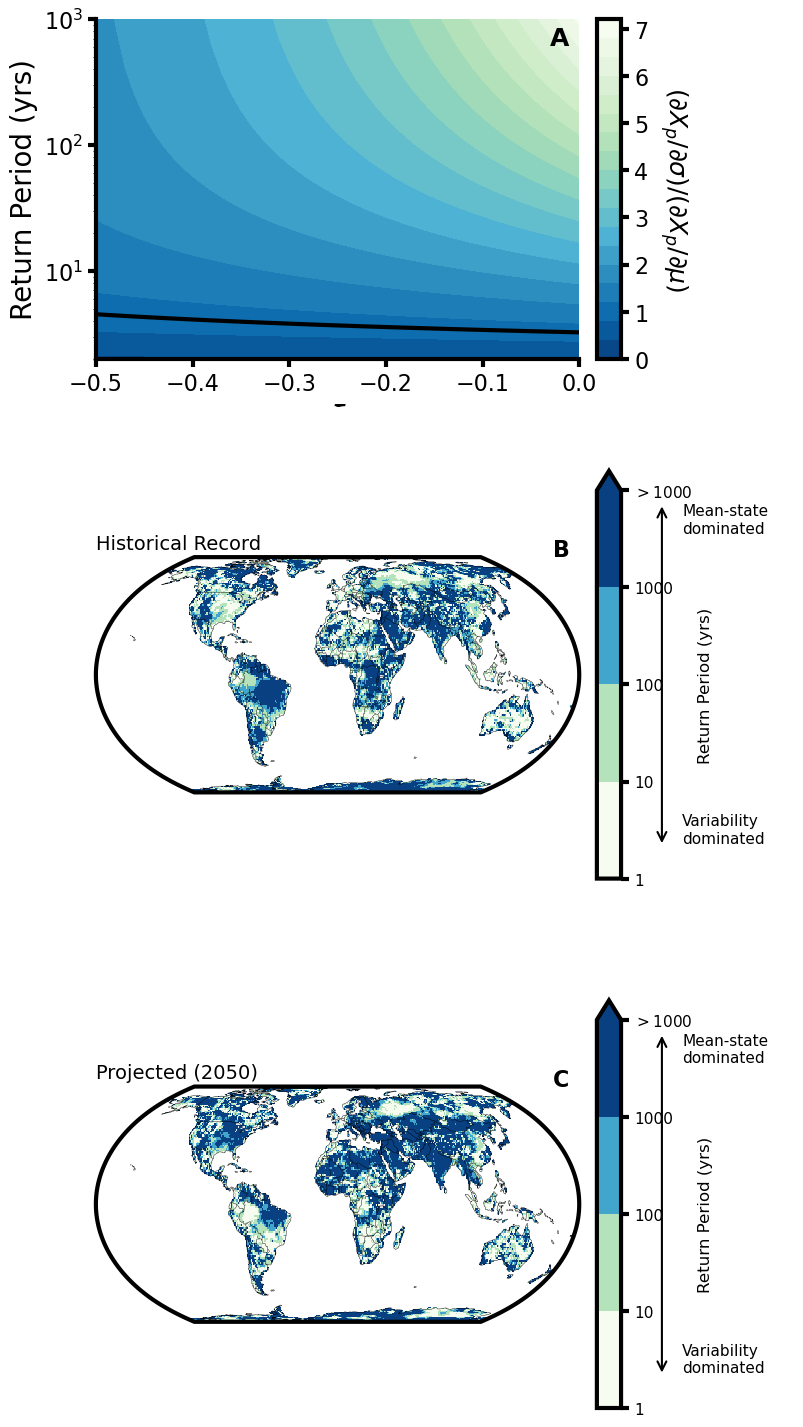

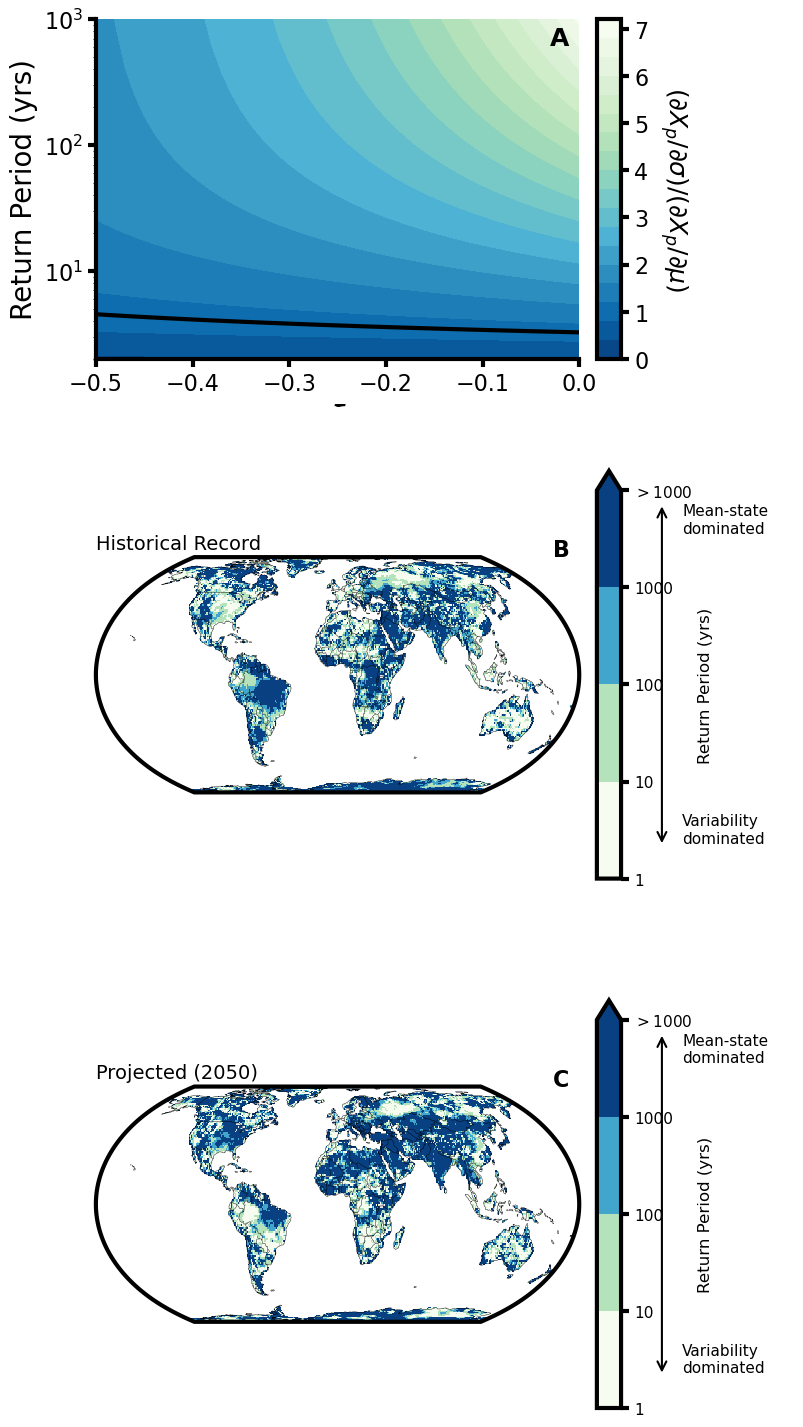

In [14]:
make_fig4(shapes, multiples, ret_periods_grid,
          ds1=ds_crit_gumbel_hist, ds2=ds_crit_gumbel_proj,
          save_figs=SAVE_FIGS, figs_path=FIGS_PATH)

# Print some quotable numbers

In [43]:
from evt_heat_waves.config import POP_PATH

ds_pop = xr.open_dataset(POP_PATH / 'gpw_v4_population_count_rev11_2020_1_deg.nc')
da_pop = ds_pop.population
da_pop

<xarray.DataArray 'population' (lat: 180, lon: 360)>
[64800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359

## Percent land below threshold

In [44]:
thresholds = np.array([np.log10(10), np.log10(100), np.log10(500), np.log10(1000)])

data = [ds_crit_gumbel_hist, ds_crit_klein_hist, ds_crit_minxi_hist]
data_proj = [ds_crit_gumbel_proj, ds_crit_klein_proj, ds_crit_minxi_proj]
xis = [0.0, -0.25, -0.5]

print("---- historical record ----")
for ds, xi in zip(data, xis):
    print(f"\nxi = {xi}")
    
    for thres in thresholds:
        x = percent_above_below_threshold(
            ds.crit_ps,
            threshold=thres,
            direction='below',
            weighted=True
        )
        
        print(
            f"Percent of land area where the return period where "
            f"scale contribution is larger than location is <{10**thres:.0f} "
            f"is {x:.2f}%"
        )

---- historical record ----

xi = 0.0
Percent of land area where the return period where scale contribution is larger than location is <10 is 19.55%
Percent of land area where the return period where scale contribution is larger than location is <100 is 40.59%
Percent of land area where the return period where scale contribution is larger than location is <500 is 52.15%
Percent of land area where the return period where scale contribution is larger than location is <1000 is 55.96%

xi = -0.25
Percent of land area where the return period where scale contribution is larger than location is <10 is 14.70%
Percent of land area where the return period where scale contribution is larger than location is <100 is 23.75%
Percent of land area where the return period where scale contribution is larger than location is <500 is 27.72%
Percent of land area where the return period where scale contribution is larger than location is <1000 is 28.96%

xi = -0.5
Percent of land area where the return perio

In [50]:
print(f"---- in {PROJ_YEAR} ----")
for ds, xi in zip(data_proj, xis):
    print(f"\nxi = {xi}")
    
    for thres in thresholds:
        x = percent_above_below_threshold(
            ds.crit_ps,
            threshold=thres,
            direction='below',
            weighted=True
        )
        
        print(
            f"Percent of land area where the return period where "
            f"scale contribution is larger than location is <{10**thres:.0f} "
            f"is {x:.2f}%"
        )

---- in 2050 ----

xi = 0.0
Percent of land area where the return period where scale contribution is larger than location is <10 is 20.55%
Percent of land area where the return period where scale contribution is larger than location is <100 is 39.93%
Percent of land area where the return period where scale contribution is larger than location is <500 is 50.85%
Percent of land area where the return period where scale contribution is larger than location is <1000 is 54.95%

xi = -0.25
Percent of land area where the return period where scale contribution is larger than location is <10 is 15.17%
Percent of land area where the return period where scale contribution is larger than location is <100 is 24.48%
Percent of land area where the return period where scale contribution is larger than location is <500 is 28.10%
Percent of land area where the return period where scale contribution is larger than location is <1000 is 28.94%

xi = -0.5
Percent of land area where the return period where sc

In [14]:
for ds, xi in zip(data, xis):
    print(f"\nxi = {xi}")
    
    for thres in thresholds:
        results_dict = percent_above_below_threshold(
            ds.crit_ps,
            threshold=thres,
            direction='below',
            weighted=True,
            pop_da=da_pop
        )
        
        print(
            f"Percent of population living in an area where the return period "
            f"where scale contribution is larger than location is <{10**thres:.0f} "
            f"is {results_dict['percent_population']:.2f}%"
        )


xi = 0.0
Percent of population living in an area where the return period where scale contribution is larger than location is <10 is 18.37%
Percent of population living in an area where the return period where scale contribution is larger than location is <100 is 38.11%
Percent of population living in an area where the return period where scale contribution is larger than location is <500 is 52.09%
Percent of population living in an area where the return period where scale contribution is larger than location is <1000 is 55.89%

xi = -0.2
Percent of population living in an area where the return period where scale contribution is larger than location is <10 is 13.54%
Percent of population living in an area where the return period where scale contribution is larger than location is <100 is 18.96%
Percent of population living in an area where the return period where scale contribution is larger than location is <500 is 20.47%
Percent of population living in an area where the return period